### This part is a bit tricky because it seems that `afterglowpy` and `jetsimpy` do not want to get along...

In [1]:
import pandas as pd
import numpy as np
import afterglowpy as grb
import matplotlib.pyplot as plt

from astropy.cosmology import Planck18 as cosmo

In [2]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

In [3]:
# import theoretical light curves simulated with jetsimpy
df_jetsimpy = pd.read_pickle('/home/masson/jetsimpy/orphan_pop/data/jetsimpy_theo_lcs.pkl')
df_jetsimpy

,configs,tday,magth
0,"{'Eiso': 4.517167111058017e+53, 'lf': 652.5472...","[0.1, 0.11233240329780274, 0.12618568830660204...","[35.47299646208081, 35.104989495519014, 34.739..."
1,"{'Eiso': 4.380931490979534e+53, 'lf': 253.5265...","[0.1, 0.11233240329780274, 0.12618568830660204...","[37.77860749061069, 37.39826489375154, 37.0537..."
2,"{'Eiso': 6.065973496123566e+53, 'lf': 243.7930...","[0.1, 0.11233240329780274, 0.12618568830660204...","[19.821293267582853, 19.444904202940855, 19.08..."
3,"{'Eiso': 1.3401710574853457e+53, 'lf': 515.569...","[0.1, 0.11233240329780274, 0.12618568830660204...","[20.979920352595265, 20.657734595853036, 20.32..."
4,"{'Eiso': 1.1922672701343154e+53, 'lf': 346.306...","[0.1, 0.11233240329780274, 0.12618568830660204...","[31.888112988260396, 31.509170835235643, 31.16..."
...,...,...,...
2587,"{'Eiso': 6.716929307452065e+53, 'lf': 505.1880...","[0.1, 0.11233240329780274, 0.12618568830660204...","[27.94592340085054, 27.55378856383546, 27.1905..."
2588,"{'Eiso': 7.241857830365918e+52, 'lf': 113.0659...","[0.1, 0.11233240329780274, 0.12618568830660204...","[24.922183939039535, 24.539439303951717, 24.19..."
2589,"{'Eiso': 9.548989069495937e+53, 'lf': 860.3752...","[0.1, 0.11233240329780274, 0.12618568830660204...","[12.347549566778639, 12.412908785071757, 12.48..."
2590,"{'Eiso': 2.0531813012527492e+53, 'lf': 848.734...","[0.1, 0.11233240329780274, 0.12618568830660204...","[15.034780844577718, 15.102916770252108, 15.17..."


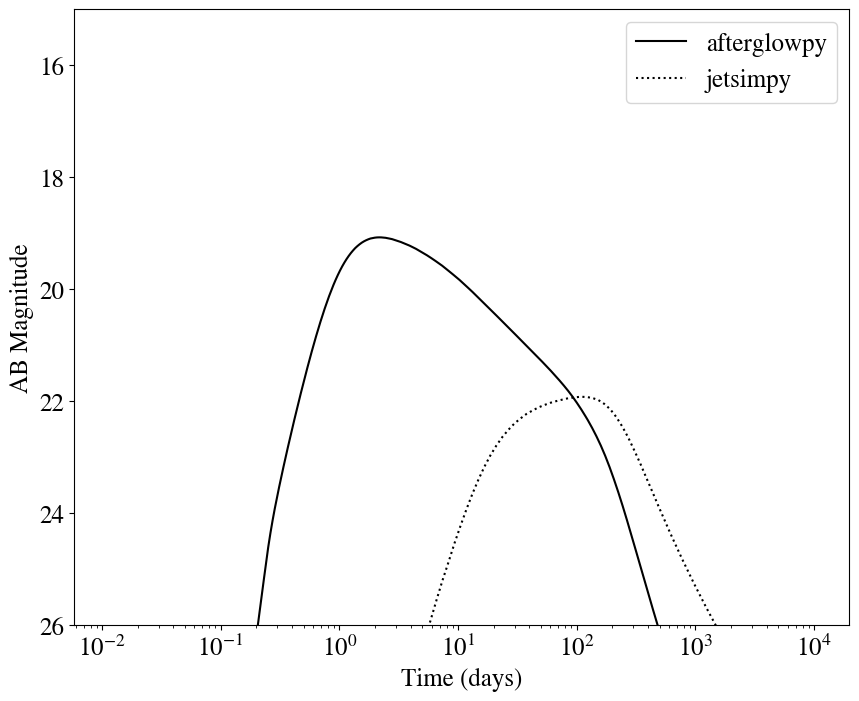

In [4]:
# choose a jetsimpy orphan to compare with
i = 7

Z = {'jetType': grb.jet.PowerLaw,
     'specType': 0,
     'b': 4,
     'thetaObs': df_jetsimpy.iloc[i]['configs']['theta_v'],
     'E0': df_jetsimpy.iloc[i]['configs']['Eiso'],
     'thetaCore': df_jetsimpy.iloc[i]['configs']['theta_c'],
     'thetaWing': df_jetsimpy.iloc[i]['configs']['theta_v']-0.1,
     'n0': df_jetsimpy.iloc[i]['configs']['n0'],
     'p': 2.5,
     'epsilon_e': 0.1,
     'epsilon_B': 0.01,
     'xi_N': 1.0,
     'd_L': df_jetsimpy.iloc[i]['configs']['d']*3.086e+24,
     'z': df_jetsimpy.iloc[i]['configs']['z']
    }

t = np.geomspace(1.0e3, 3.0e8, 300)

nu = np.empty(t.shape)
nu[:] = 5.0e14

# compute the light curve with afterglowpy for this configuration
flux = grb.fluxDensity(t, nu, **Z)
mag = -2.5 * np.log10(flux*1.0e-26) - 48.6

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10,8))

# plot the light curves for afterglowpy and jetsimpy models
plt.plot(t*grb.sec2day, mag, color='k', label='afterglowpy')
plt.plot(df_jetsimpy.iloc[i]['tday'], df_jetsimpy.iloc[i]['magth'], color='k', ls=':', label='jetsimpy')

#plt.plot(t*grb.sec2day, flux, color='k')
plt.gca().invert_yaxis()
plt.ylim(26, 15)
#plt.ylim(1e-12, 1e-3)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Time (days)')
plt.ylabel('AB Magnitude')
plt.legend()

plt.show()

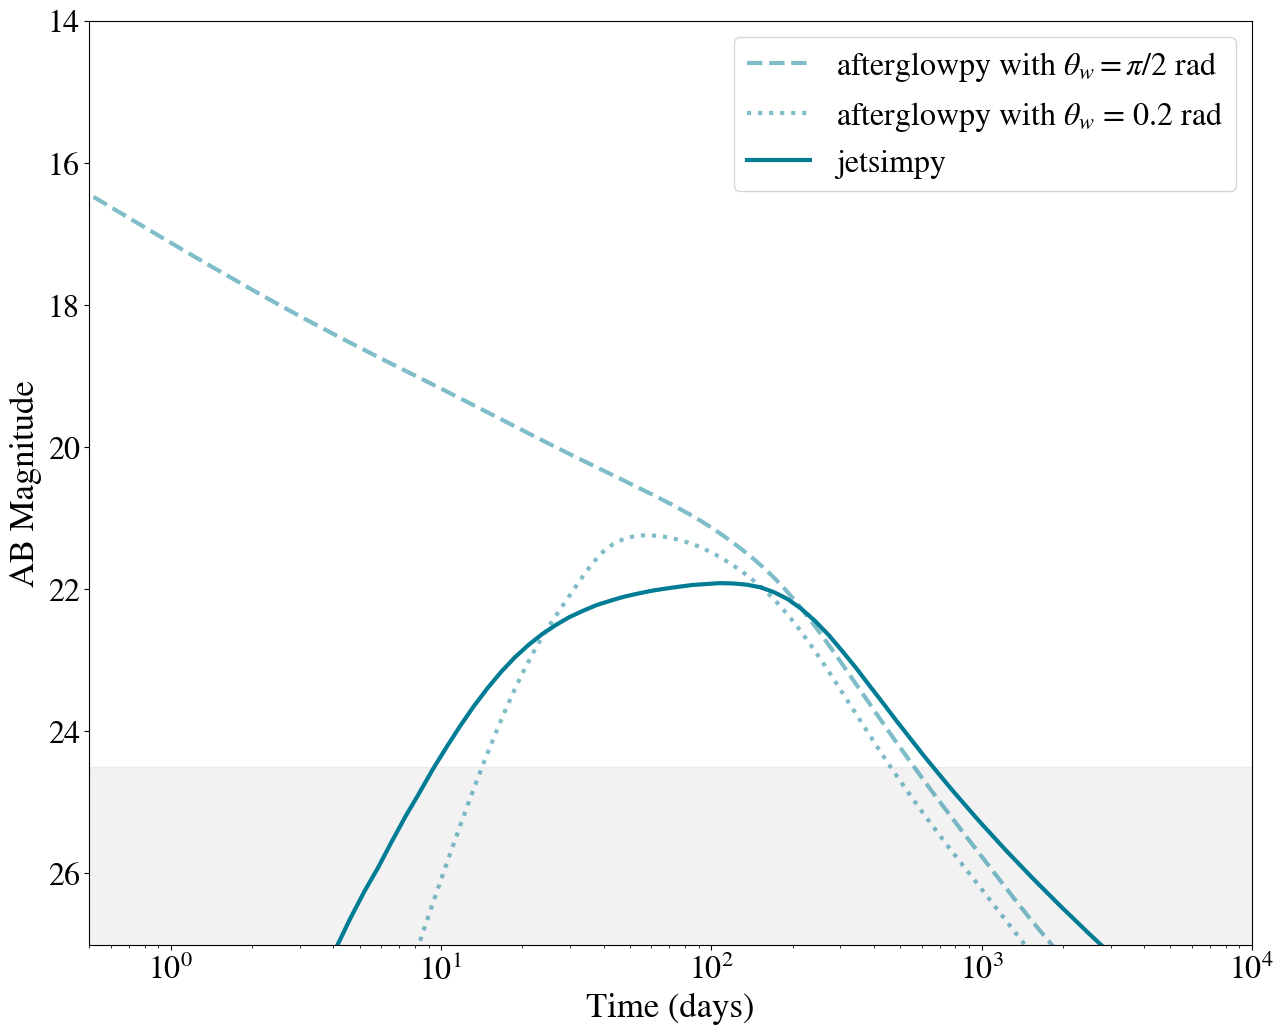

In [5]:
i = 7

Z = {'jetType': grb.jet.PowerLaw,
     'specType': 0,
     'b': 4,
     'thetaObs': df_jetsimpy.iloc[i]['configs']['theta_v'],
     'E0': df_jetsimpy.iloc[i]['configs']['Eiso'],
     'thetaCore': df_jetsimpy.iloc[i]['configs']['theta_c'],
     'thetaWing': df_jetsimpy.iloc[i]['configs']['theta_v']-0.1,
     'n0': df_jetsimpy.iloc[i]['configs']['n0'],
     'p': 2.2,
     'epsilon_e': 0.1,
     'epsilon_B': 0.01,
     'xi_N': 1.0,
     'd_L': df_jetsimpy.iloc[i]['configs']['d']*3.086e+24,
     'z': df_jetsimpy.iloc[i]['configs']['z']
    }

# compute the light curve with afterglowpy for this configuration
flux = grb.fluxDensity(t, nu, **Z)
mag = -2.5 * np.log10(flux*1.0e-26) - 48.6


t = np.geomspace(1.0e3, 3.0e8, 300)

nu = np.empty(t.shape)
nu[:] = 5.0e14   

colors = ['#007c95', '#00b1cb', '#00344b']


plt.rcParams.update({'font.size': 23})
plt.figure(figsize=(15,12))


# plot afterglowpy orphan for thetaWing = pi/2
Z['thetaWing'] = np.pi/2
Fnu = grb.fluxDensity(t, nu, **Z)*1.0e-3
mag = -2.5 * np.log10(Fnu*1.0e-23) - 48.6

plt.plot(t*grb.sec2day, mag, color=colors[0], alpha=0.5, ls='--', lw=3, label = r'afterglowpy with $\theta_w = \pi/2$ rad')


# plot afterglowpy orphan for thetaWing < pi/2
Z['thetaWing'] = 0.2
Fnu = grb.fluxDensity(t, nu, **Z)*1.0e-3
mag = -2.5 * np.log10(Fnu*1.0e-23) - 48.6

plt.plot(t*grb.sec2day, mag, color=colors[0], alpha=0.5, ls=':', lw=3, label = fr'afterglowpy with $\theta_w$ = 0.2 rad')


# plot the light curve for jetsimpy
plt.plot(df_jetsimpy.iloc[i]['tday'], df_jetsimpy.iloc[i]['magth'], color=colors[0], lw=3, label = 'jetsimpy')


plt.xlabel('Time (days)', fontsize=25)
plt.ylabel('AB Magnitude', fontsize=25)
plt.gca().invert_yaxis()
plt.xscale('log')
plt.fill_between([1e-3, 1e5], 24.5, 31., color='k', alpha=0.05)
plt.xlim(0.5, 10000)
plt.ylim(27, 14)
plt.legend()


#plt.savefig('../figures/orphan_lc_th_jetsimpy_afterglowpy_lambda_300.pdf', format="pdf", bbox_inches="tight", transparent=True)
plt.show()

## Compare features

In [6]:
jetsimpy_configs = pd.read_pickle('/home/masson/jetsimpy/orphan_pop/data/pseudo_obs_jetsimpy_5pts.pkl')

In [7]:
features_jetsimpy = pd.read_csv('/home/masson/jetsimpy/orphan_pop/data/features_jetsimpy.txt', sep='\t')
features_jetsimpy = features_jetsimpy.rename(columns={"A_over_B": "A/B"})

In [8]:
features_all = pd.read_pickle('/home/masson/afterglowpy/data/orphans_elasticc_features.pkl')
features_afterglowpy = features_all[features_all['type']=='orphans']

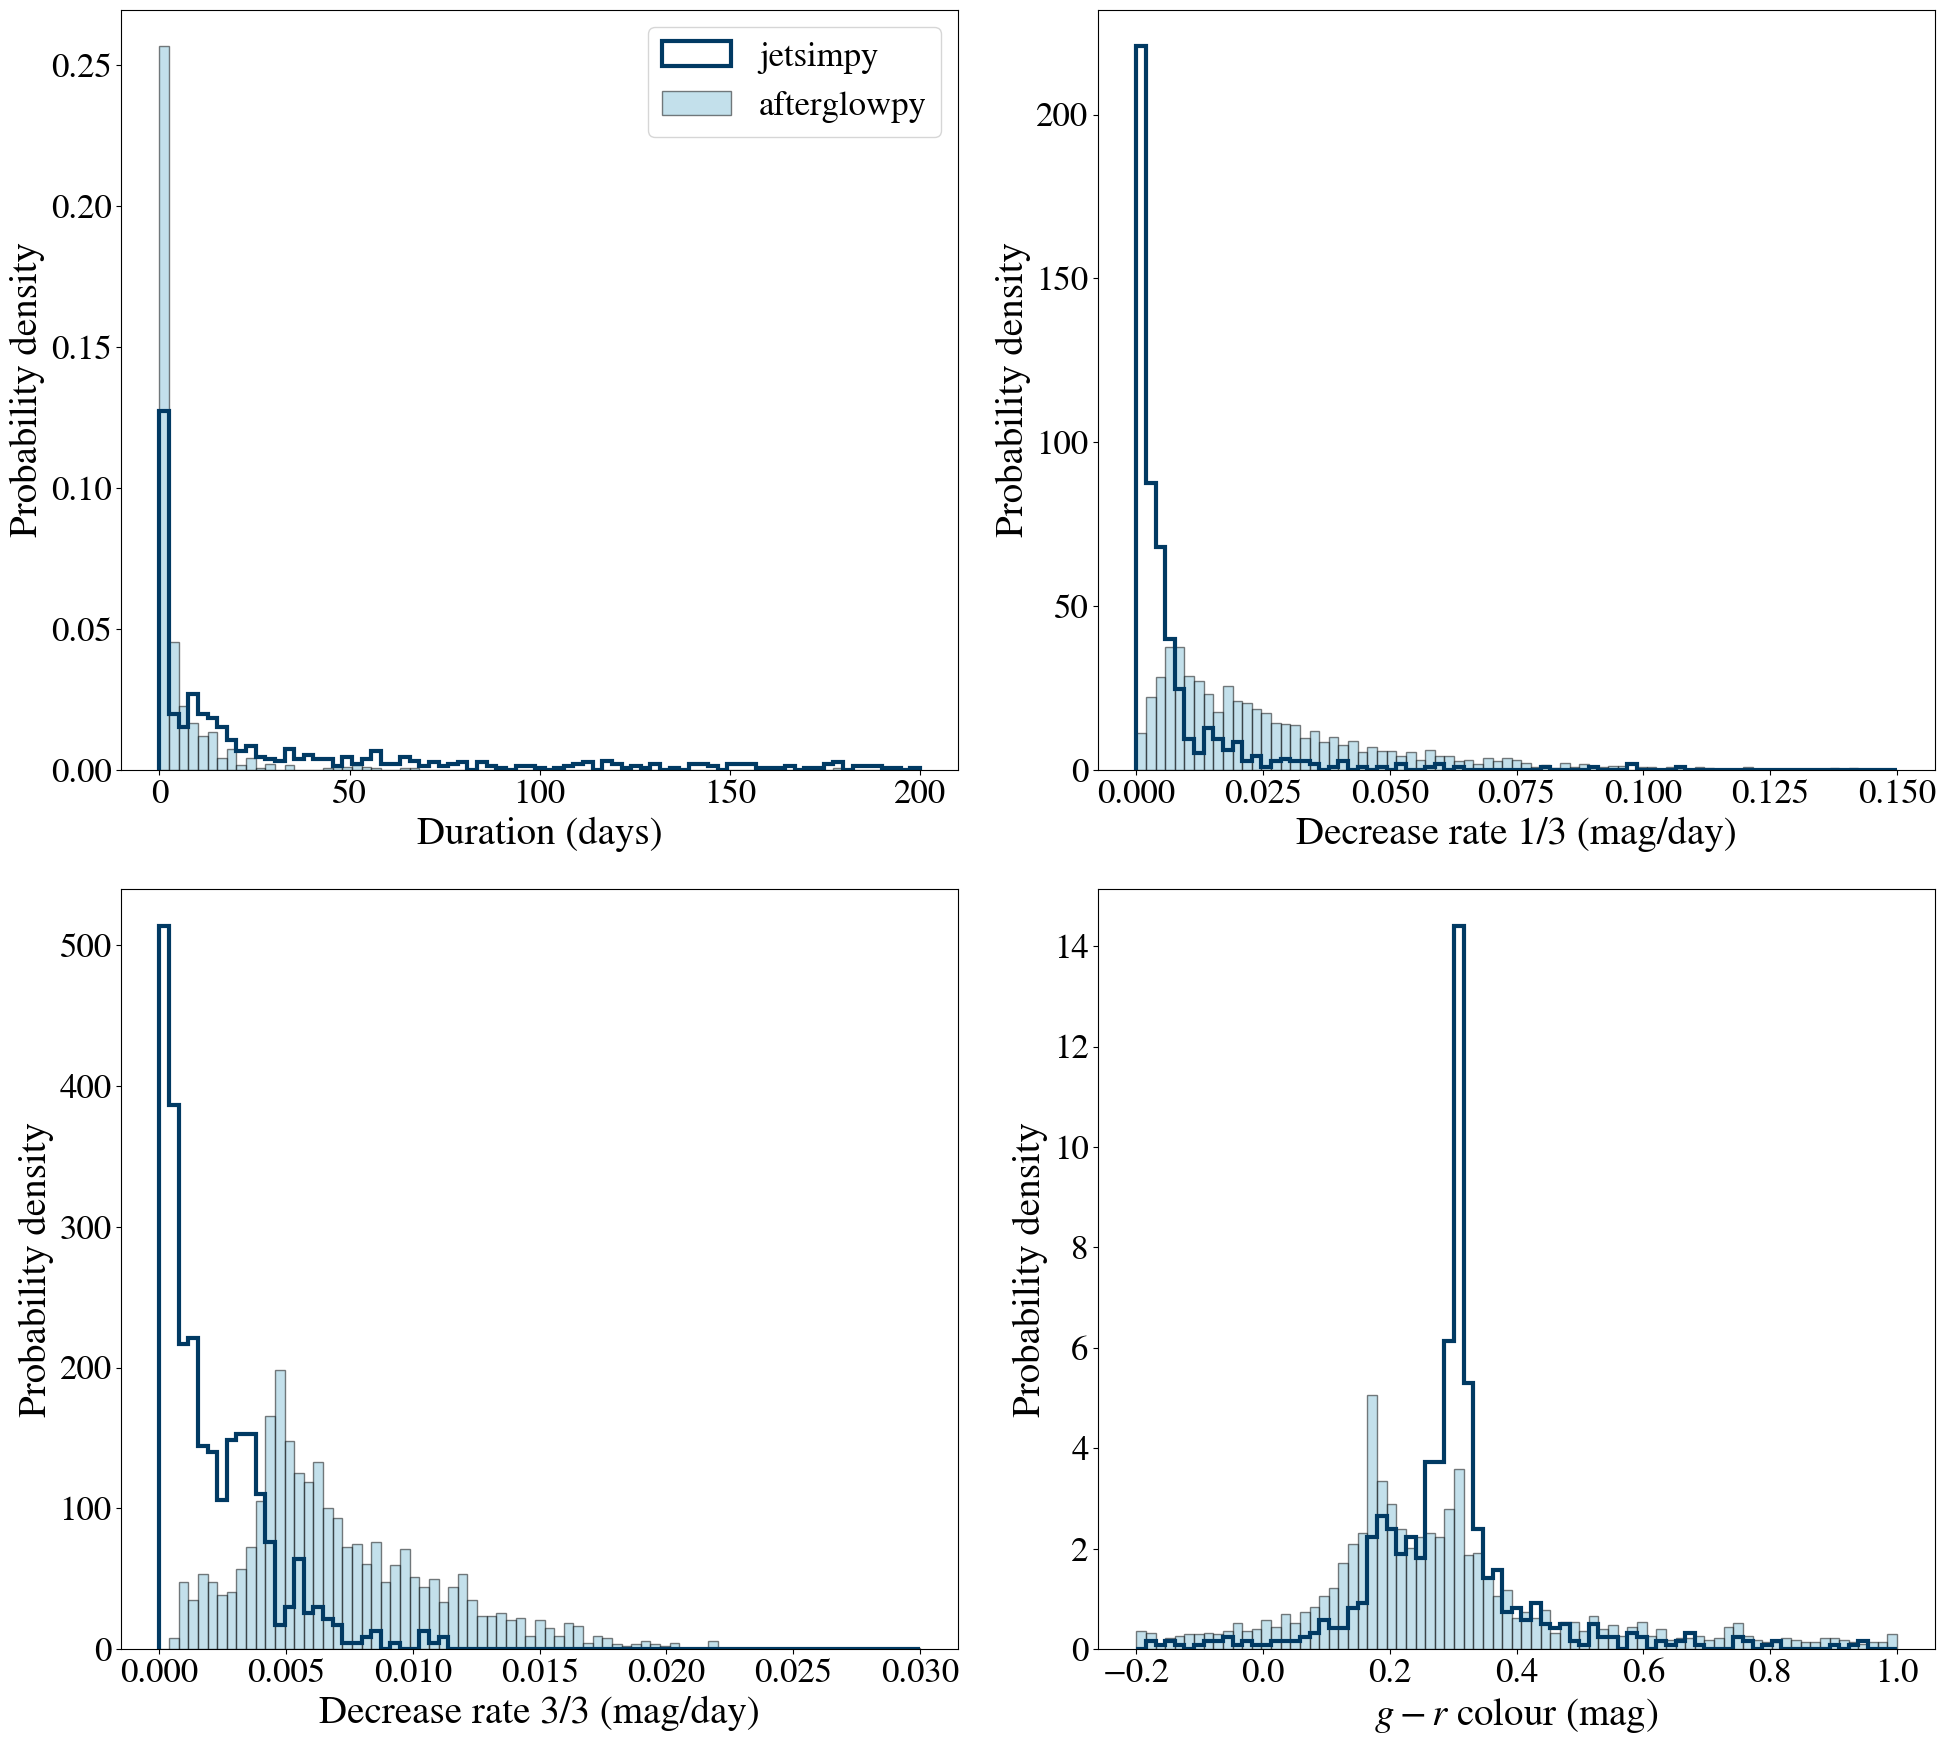

In [9]:
features = ['duration', 'increase_rate', 'decrease_rate_1', 'decrease_rate_3', 'g-r']
features_labels = ['Duration (days)', 'Increase rate (mag/day)', 'Decrease rate 1/3 (mag/day)', 
                   'Decrease rate 3/3 (mag/day)', '$g-r$ colour (mag)']

plt.rcParams.update({'font.size': 25})
fig, axes = plt.subplots(figsize=(20,18), nrows=2, ncols=2)

for i in range(4):
    ax = axes[i//2, i%2]
    
    if i==0:
        bin_edges = np.linspace(0, 200, 80)
        ax.hist(features_jetsimpy[features[i]][features_jetsimpy[features[i]]!=0], bins=bin_edges, histtype='step', density=True, color='#013a63', linewidth=3, label='jetsimpy')
        ax.hist(features_afterglowpy[features[i]][features_afterglowpy[features[i]]!=0], bins=bin_edges, edgecolor='k', density=True, color='#89c2d9', alpha=0.5, label='afterglowpy')
        ax.set_ylabel("Probability density", fontsize=28)
        ax.set_xlabel(features_labels[i], fontsize=28)
        ax.legend()
        
    elif i==1:
        bin_edges = np.linspace(0.0, 0.15, 80)
        ax.hist(features_jetsimpy[features[i+1]][features_jetsimpy[features[i+1]]!=0], bins=bin_edges, histtype='step', density=True, color='#013a63', linewidth=3, label='jetsimpy')
        ax.hist(features_afterglowpy[features[i+1]][features_afterglowpy[features[i+1]]!=0], bins=bin_edges, edgecolor='k', density=True, color='#89c2d9', alpha=0.5, label='afterglowpy')
        ax.set_ylabel("Probability density", fontsize=28)
        ax.set_xlabel(features_labels[i+1], fontsize=28)
        
    elif i==2:
        bin_edges = np.linspace(0.0, 0.03, 80)
        ax.hist(features_jetsimpy[features[i+1]][features_jetsimpy[features[i+1]]!=0], bins=bin_edges, histtype='step', density=True, color='#013a63', linewidth=3, label='jetsimpy')
        ax.hist(features_afterglowpy[features[i+1]][features_afterglowpy[features[i+1]]!=0], bins=bin_edges, edgecolor='k', density=True, color='#89c2d9', alpha=0.5, label='afterglowpy')
        ax.set_ylabel("Probability density", fontsize=28)
        ax.set_xlabel(features_labels[i+1], fontsize=28)
    
    elif i==3:
        bin_edges = np.linspace(-0.2, 1., 80)
        ax.hist(features_jetsimpy[features[i+1]], bins=bin_edges, histtype='step', density=True, color='#013a63', linewidth=3, label='jetsimpy')
        ax.hist(features_afterglowpy[features[i+1]], bins=bin_edges, edgecolor='k', density=True, color='#89c2d9', alpha=0.5, label='afterglowpy')
        ax.set_ylabel("Probability density", fontsize=28)
        ax.set_xlabel(features_labels[i+1], fontsize=28)

plt.tight_layout() 

#plt.savefig('../figures/features_distrib_compare_jetsimpy_afterglowpy.pdf', format="pdf", bbox_inches="tight", transparent=True)
plt.show()

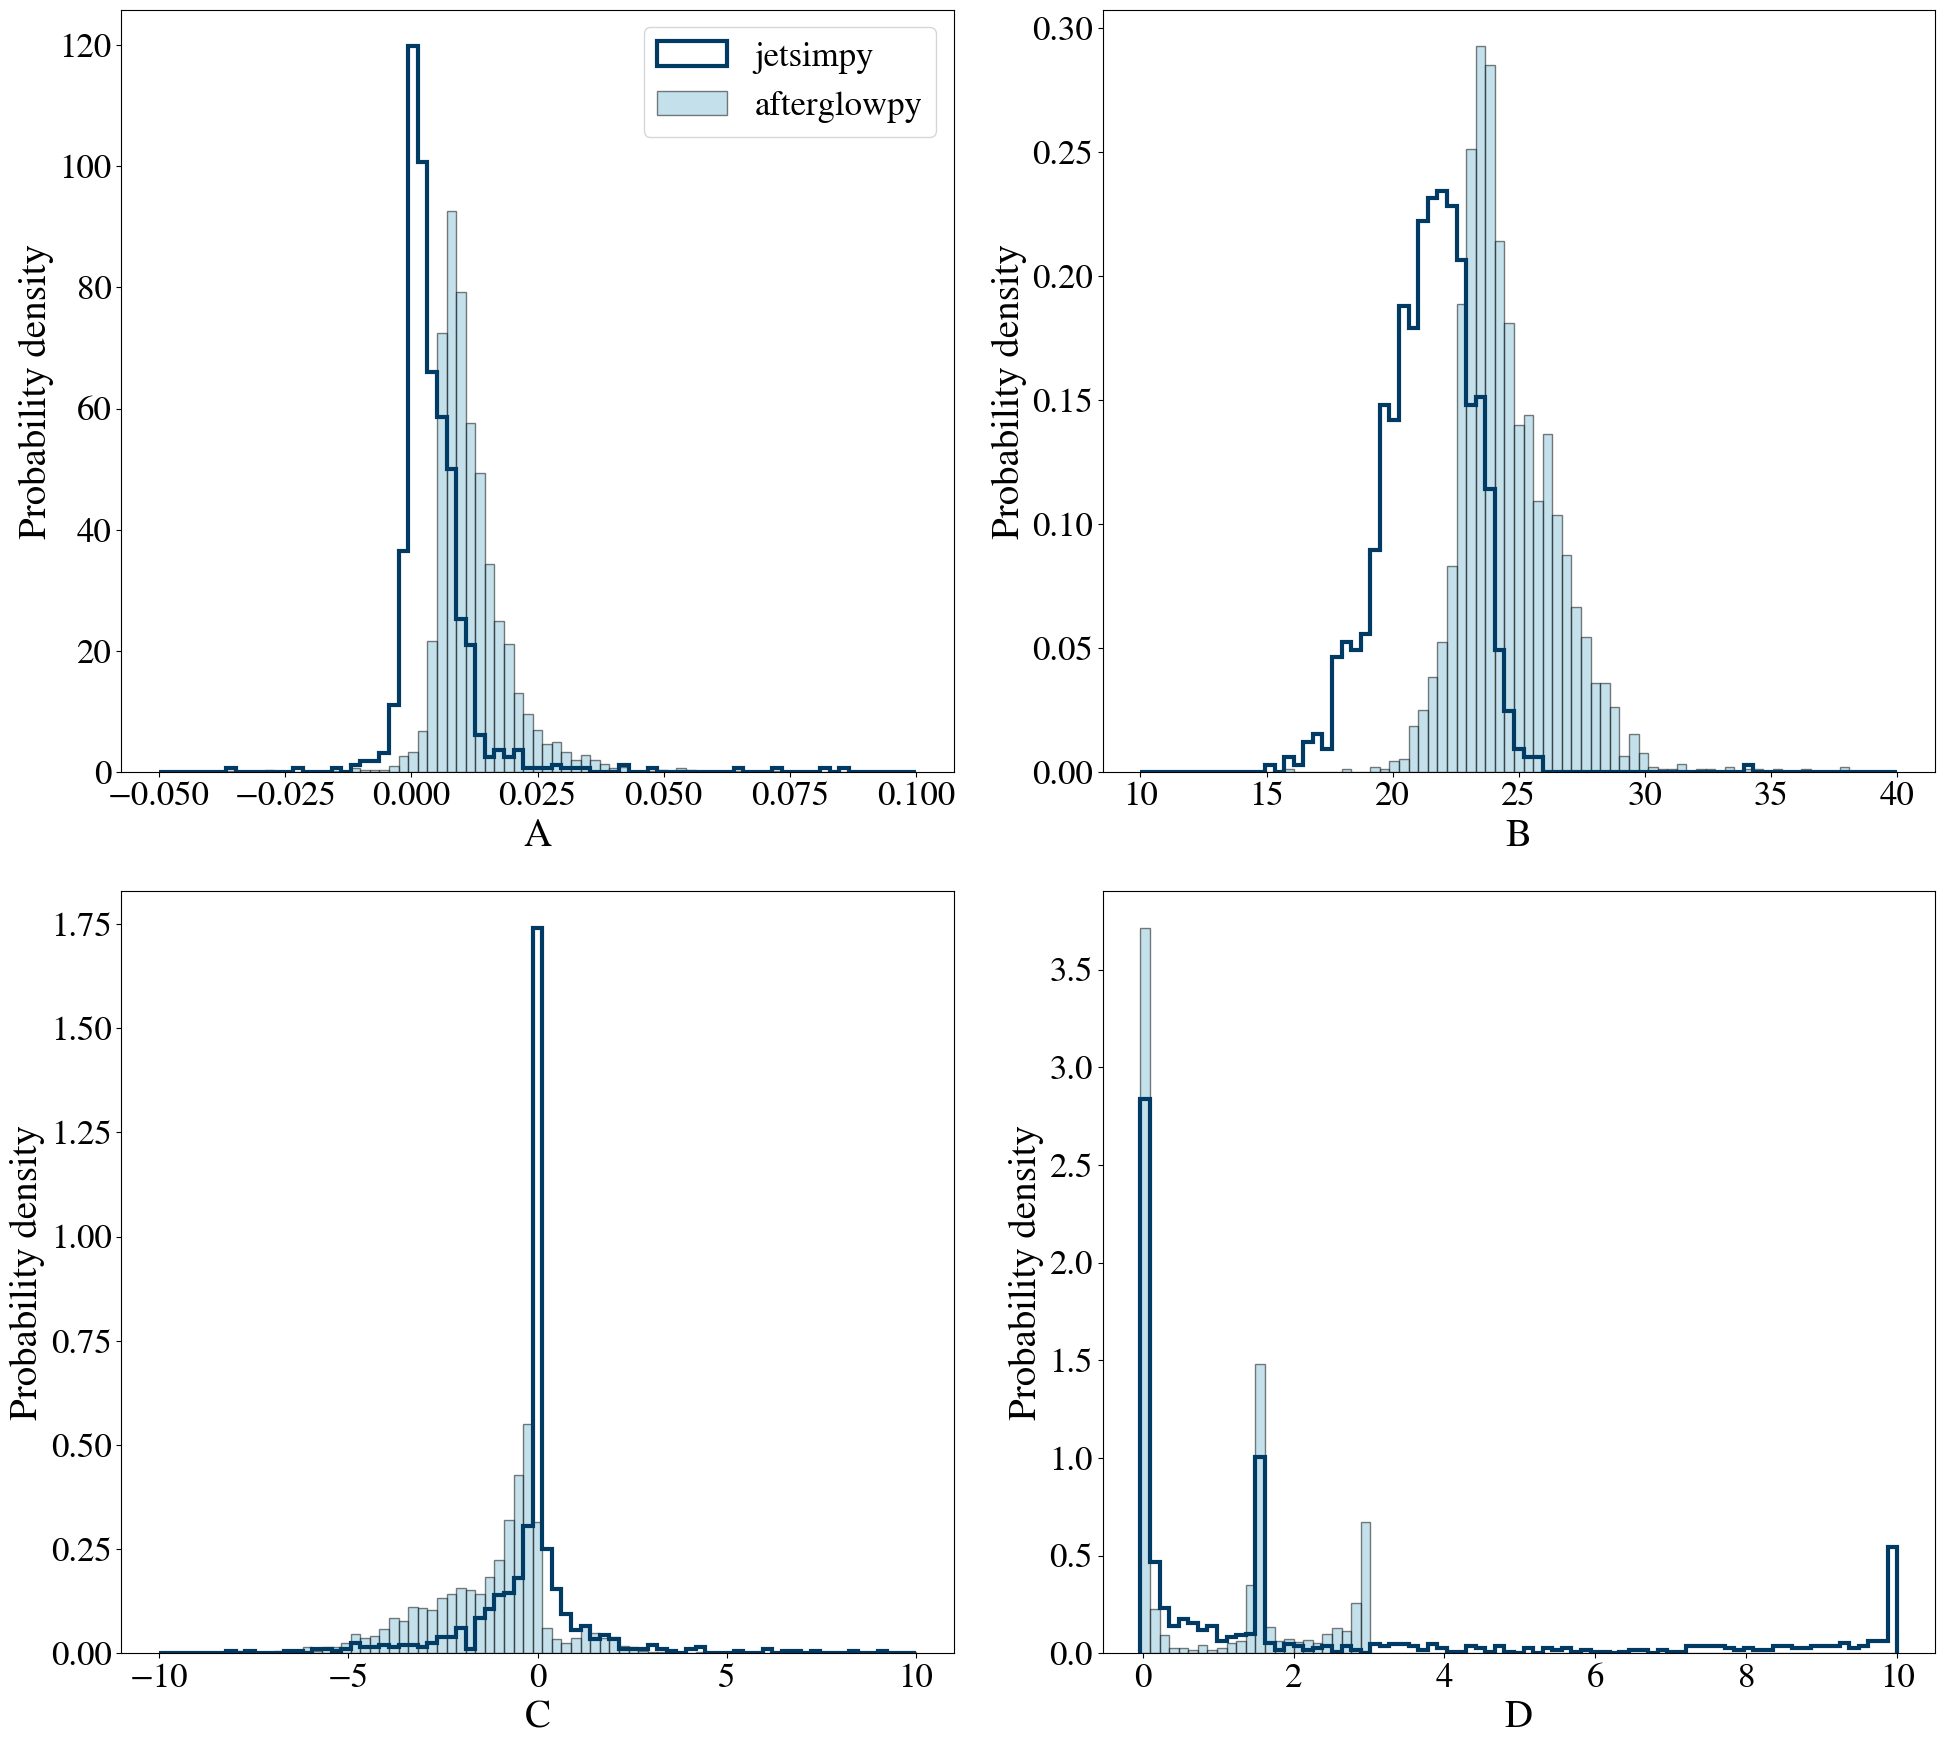

In [10]:
features = ['A', 'B', 'C', 'D']

plt.rcParams.update({'font.size': 25})
fig, axes = plt.subplots(figsize=(20,18), nrows=2, ncols=2)

for i in range(4):
    ax = axes[i//2, i%2]
    
    if i==0:
        bin_edges = np.linspace(-0.05, 0.1, 80)
        ax.hist(features_jetsimpy[features[i]], bins=bin_edges, histtype='step', density=True, color='#013a63', linewidth=3, label='jetsimpy')
        ax.hist(features_afterglowpy[features[i]], bins=bin_edges, edgecolor='k', density=True, color='#89c2d9', alpha=0.5, label='afterglowpy')
        ax.set_ylabel("Probability density", fontsize=28)
        ax.set_xlabel(features[i], fontsize=28)
        ax.legend()
        
    elif i==1:
        bin_edges = np.linspace(10.0, 40., 80)
        ax.hist(features_jetsimpy[features[i]], bins=bin_edges, histtype='step', density=True, color='#013a63', linewidth=3, label='jetsimpy')
        ax.hist(features_afterglowpy[features[i]], bins=bin_edges, edgecolor='k', density=True, color='#89c2d9', alpha=0.5, label='afterglowpy')
        ax.set_ylabel("Probability density", fontsize=28)
        ax.set_xlabel(features[i], fontsize=28)
        
    elif i==2:
        bin_edges = np.linspace(-10.0, 10., 80)
        ax.hist(features_jetsimpy[features[i]], bins=bin_edges, histtype='step', density=True, color='#013a63', linewidth=3, label='jetsimpy')
        ax.hist(features_afterglowpy[features[i]], bins=bin_edges, edgecolor='k', density=True, color='#89c2d9', alpha=0.5, label='afterglowpy')
        ax.set_ylabel("Probability density", fontsize=28)
        ax.set_xlabel(features[i], fontsize=28)
    
    elif i==3:
        bin_edges = np.linspace(-0.03, 10., 80)
        ax.hist(features_jetsimpy[features[i]], bins=bin_edges, histtype='step', density=True, color='#013a63', linewidth=3, label='jetsimpy')
        ax.hist(features_afterglowpy[features[i]], bins=bin_edges, edgecolor='k', density=True, color='#89c2d9', alpha=0.5, label='afterglowpy')
        ax.set_ylabel("Probability density", fontsize=28)
        ax.set_xlabel(features[i], fontsize=28)

plt.tight_layout() 

#plt.savefig('../figures/fit_features_distrib_compare_jetsimpy_afterglowpy.pdf', format="pdf", bbox_inches="tight", transparent=True)
plt.show()

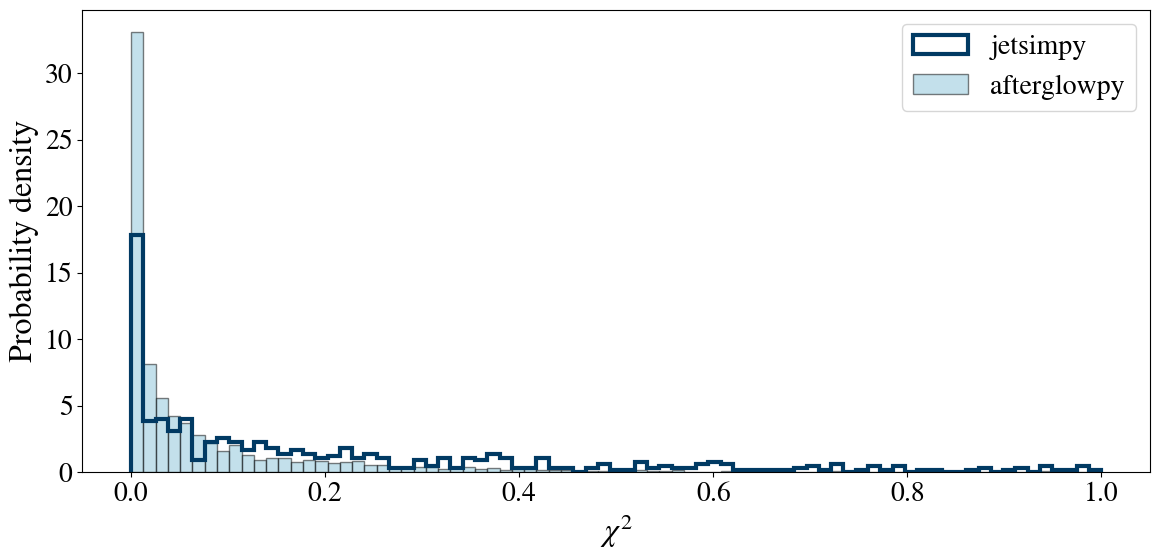

In [11]:
plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(12, 6))

bin_edges = np.linspace(0.0, 1., 80)

plt.hist(features_jetsimpy['chi2'], bins=bin_edges, histtype='step', density=True, color='#013a63', linewidth=3, label='jetsimpy')
plt.hist(features_afterglowpy['chi2'], bins=bin_edges, density=True, color='#89c2d9', alpha=0.5, edgecolor='black', label='afterglowpy')
plt.xlabel(r"$\chi^2$", fontsize=23)
plt.ylabel("Probability density", fontsize=23)
plt.legend()

plt.tight_layout()

#plt.savefig("/home/masson/afterglowpy/figures/chi2_distrib_compare_jetsimpy_afterglowpy.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

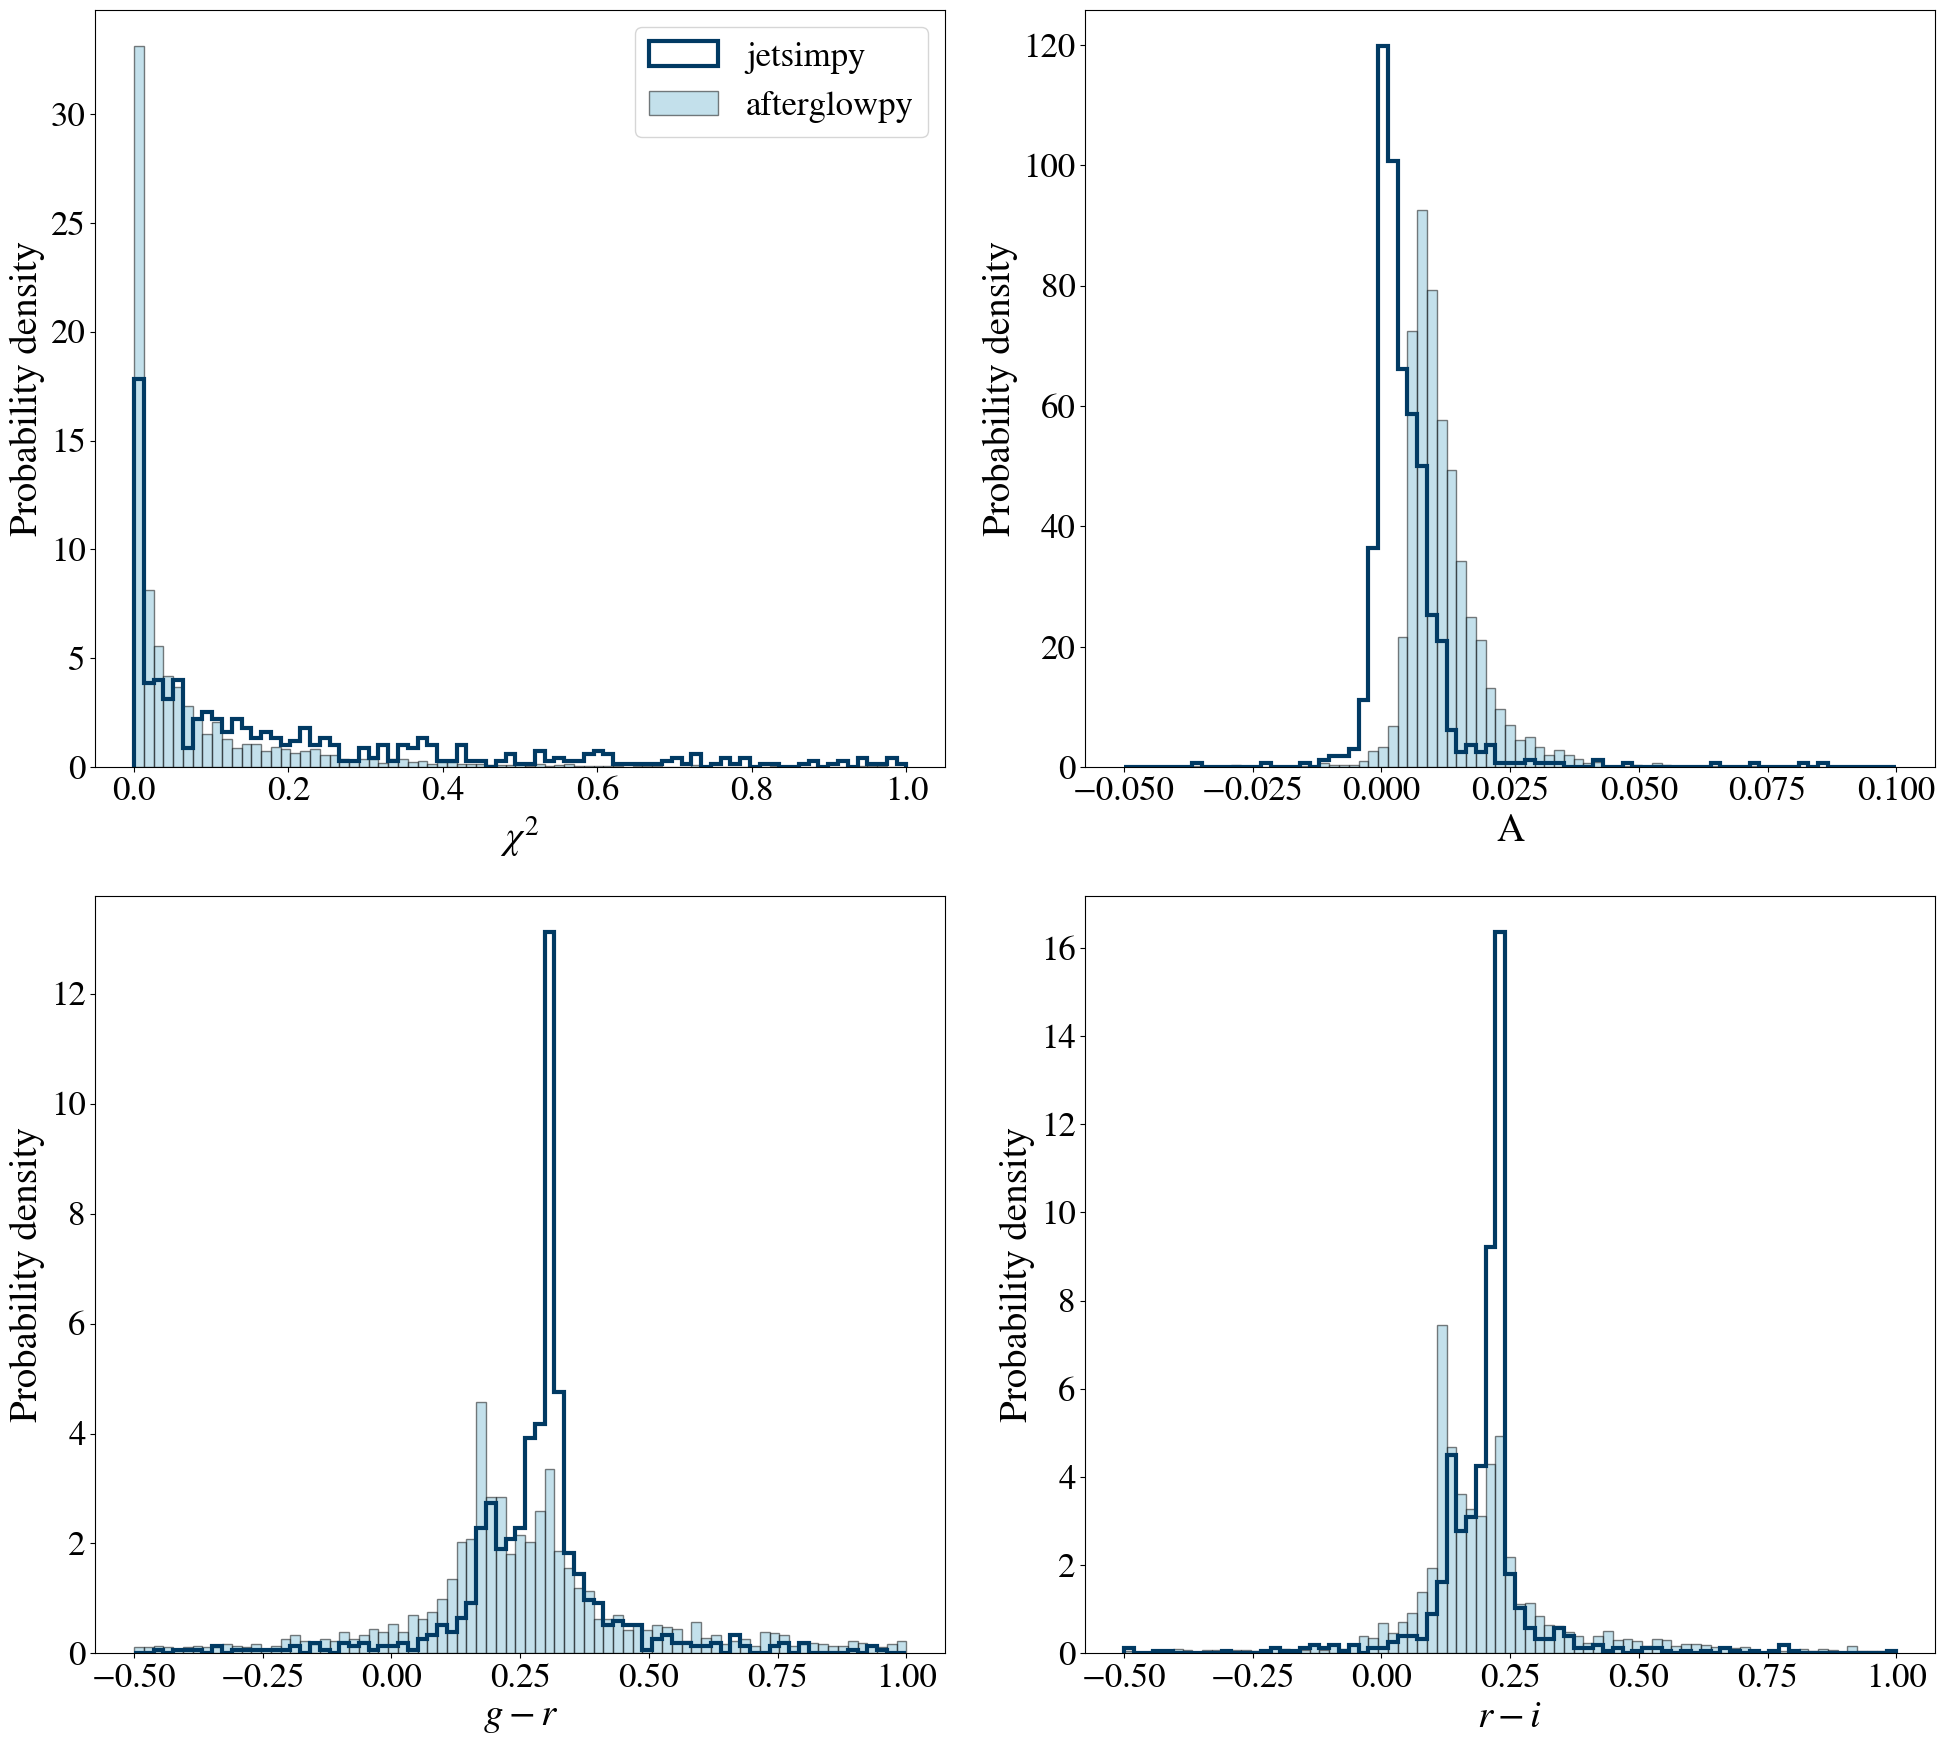

In [12]:
features = ['chi2', 'A', 'g-r', 'r-i']
features_labels = [r'$\chi^2$', 'A', '$g-r$', '$r-i$']

plt.rcParams.update({'font.size': 25})
fig, axes = plt.subplots(figsize=(20,18), nrows=2, ncols=2)

for i in range(4):
    ax = axes[i//2, i%2]
    
    if i==0:
        bin_edges = np.linspace(0., 1., 80)
        ax.hist(features_jetsimpy[features[i]], bins=bin_edges, histtype='step', density=True, color='#013a63', linewidth=3, label='jetsimpy')
        ax.hist(features_afterglowpy[features[i]], bins=bin_edges, edgecolor='k', density=True, color='#89c2d9', alpha=0.5, label='afterglowpy')
        ax.set_ylabel("Probability density", fontsize=28)
        ax.set_xlabel(features_labels[i], fontsize=28)
        ax.legend()
        
    elif i==1:
        bin_edges = np.linspace(-0.05, 0.1, 80)
        ax.hist(features_jetsimpy[features[i]], bins=bin_edges, histtype='step', density=True, color='#013a63', linewidth=3, label='jetsimpy')
        ax.hist(features_afterglowpy[features[i]], bins=bin_edges, edgecolor='k', density=True, color='#89c2d9', alpha=0.5, label='afterglowpy')
        ax.set_ylabel("Probability density", fontsize=28)
        ax.set_xlabel(features_labels[i], fontsize=28)
        
    elif i==2:
        bin_edges = np.linspace(-0.5, 1., 80)
        ax.hist(features_jetsimpy[features[i]], bins=bin_edges, histtype='step', density=True, color='#013a63', linewidth=3, label='jetsimpy')
        ax.hist(features_afterglowpy[features[i]], bins=bin_edges, edgecolor='k', density=True, color='#89c2d9', alpha=0.5, label='afterglowpy')
        ax.set_ylabel("Probability density", fontsize=28)
        ax.set_xlabel(features_labels[i], fontsize=28)
    
    elif i==3:
        bin_edges = np.linspace(-0.5, 1., 80)
        ax.hist(features_jetsimpy[features[i]], bins=bin_edges, histtype='step', density=True, color='#013a63', linewidth=3, label='jetsimpy')
        ax.hist(features_afterglowpy[features[i]], bins=bin_edges, edgecolor='k', density=True, color='#89c2d9', alpha=0.5, label='afterglowpy')
        ax.set_ylabel("Probability density", fontsize=28)
        ax.set_xlabel(features_labels[i], fontsize=28)

plt.tight_layout() 

#plt.savefig('../figures/main_features_distrib_compare_jetsimpy_afterglowpy.pdf', format="pdf", bbox_inches="tight", transparent=True)
plt.show()